# XAI Enhancement Playground

24 × 5 t-SNE grid iterated over multiple experiment folders.

**Color encoding** — hue family = class · shade = concentration (light → low, dark → high)

In [11]:
import os, sys
from pathlib import Path
try:
    _nb = globals().get('__vsc_ipynb_file__')
    if _nb: os.chdir(os.path.dirname(os.path.dirname(_nb)))
except Exception:
    pass
sys.path.insert(0, 'utils')
sys.path.insert(0, 'utils/model_training')
print('cwd:', os.getcwd())

cwd: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [12]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')

import types as _types
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import tensorflow as tf
from pathlib import Path
from sklearn.manifold import TSNE

import config
import model_utils_gated
import model_utils_mtl
import model_utils_supcon
from model_utils_mtl    import CurriculumMTLModel
from model_utils_rcfd   import (RCFDModel, RCFDSupConMTLModel,
                                 RCFDBranch2MTLModel, RCFDBranch3MTLModel)
from model_utils_supcon import (SupConModel, SupConMTLModel,
                                 SupConBranch2STModel,  SupConBranch2MTLModel,
                                 SupConBranch3STModel,  SupConBranch3MTLModel,
                                 CurriculumSupConMTLModel,
                                 CurriculumBranch2MTLModel,
                                 CurriculumBranch3MTLModel)
print('TF:', tf.__version__)

TF: 2.16.2


In [13]:
# ── Keras 3 compat: Lambda layers in old .keras files ────────────────────────
tf.keras.layers.Lambda.compute_output_shape = lambda self, input_shape=None: input_shape

_orig_lambda_call = tf.keras.layers.Lambda.call
def _lambda_call_tf_fix(self, inputs, mask=None, training=None):
    fn = self.function
    if fn is not None and callable(fn) and 'tf' not in fn.__globals__:
        self.function = _types.FunctionType(
            fn.__code__, {**fn.__globals__, 'tf': tf},
            fn.__name__, fn.__defaults__, fn.__closure__)
    return _orig_lambda_call(self, inputs, mask=mask, training=training)
tf.keras.layers.Lambda.call = _lambda_call_tf_fix
print('Lambda patches applied.')

Lambda patches applied.


In [14]:
# ── Grid constants (shared across all folders) ────────────────────────────────
_BACKBONES  = ['cnn', 'gru', 'transformer', 'cnn_gru_dual', 'cnn_trans_dual']
_BB_LABELS  = ['CNN', 'GRU', 'Trans', 'CNN+GRU', 'CNN+Trans']
_BB_KEY_PFX = {'transformer': 'trans'}

_FAMILIES = [
    ('ST',         'ST'),
    ('MTL',        'MTL'),
    ('CL',         'CL'),
    ('CNN RCFD',   'CNN_RCFD'),
    ('GRU RCFD',   'GRU_RCFD'),
    ('Trans RCFD', 'TRANS_RCFD'),
]
_RCFD_ENC_TAG = {'CNN_RCFD': 'cnn', 'GRU_RCFD': 'gru', 'TRANS_RCFD': 'trans'}
_SC_VARIANTS  = [0, 1, 2, 3]
_N_ROWS       = len(_FAMILIES) * 4
_N_COLS       = len(_BACKBONES)


def _combo_key(family, sc, bb):
    pfx = _BB_KEY_PFX.get(bb, bb)
    if family == 'ST':
        sfx = {0: '', 1: '_supcon', 2: '_supcon2', 3: '_supcon3'}[sc]
        if sc in (2, 3) and bb not in ('cnn_gru_dual', 'cnn_trans_dual'): return None
        return f'{pfx}{sfx}'
    if family == 'MTL':
        sfx = {0: '_mtl', 1: '_supcon_mtl', 2: '_supcon2_mtl', 3: '_supcon3_mtl'}[sc]
        if sc in (2, 3) and bb not in ('cnn_gru_dual', 'cnn_trans_dual'): return None
        return f'{pfx}{sfx}'
    if family == 'CL':
        if bb not in ('cnn_gru_dual', 'cnn_trans_dual'): return None
        sfx = {0: '_cl_mtl', 1: '_cl_supcon_mtl', 2: '_cl_supcon2_mtl', 3: '_cl_supcon3_mtl'}[sc]
        return f'{pfx}{sfx}'
    if family in _RCFD_ENC_TAG:
        if bb not in ('cnn_gru_dual', 'cnn_trans_dual'): return None
        enc  = _RCFD_ENC_TAG[family]
        dual = 'cgd' if bb == 'cnn_gru_dual' else 'ctd'
        sfx  = {0: '', 1: '_supcon_mtl', 2: '_supcon2_mtl', 3: '_supcon3_mtl'}[sc]
        return f'{enc}_rcfd_{dual}{sfx}'
    return None


def _key_to_filename(key):
    """Result-storage key → .keras file stem (gru→bigru, trans*→transformer*)."""
    if key is None: return None
    if key == 'gru': return 'bigru'
    if key.startswith('trans') and 'rcfd' not in key:
        return 'transformer' + key[len('trans'):]
    return key


# Pre-built grid list — (row_idx, row_label, col_idx, col_label, combo_key, file_stem)
_GRID = [
    (fi * 4 + si, f'{fl} SC{sc}', ci, _BB_LABELS[ci],
     _combo_key(ft, sc, bb), _key_to_filename(_combo_key(ft, sc, bb)))
    for fi, (fl, ft) in enumerate(_FAMILIES)
    for si, sc    in enumerate(_SC_VARIANTS)
    for ci, bb    in enumerate(_BACKBONES)
]

# Custom objects for load_model
_CUSTOM_OBJECTS = {
    'SupConModel':               SupConModel,
    'SupConMTLModel':            SupConMTLModel,
    'SupConBranch2STModel':      SupConBranch2STModel,
    'SupConBranch2MTLModel':     SupConBranch2MTLModel,
    'SupConBranch3STModel':      SupConBranch3STModel,
    'SupConBranch3MTLModel':     SupConBranch3MTLModel,
    'CurriculumMTLModel':        CurriculumMTLModel,
    'CurriculumSupConMTLModel':  CurriculumSupConMTLModel,
    'CurriculumBranch2MTLModel': CurriculumBranch2MTLModel,
    'CurriculumBranch3MTLModel': CurriculumBranch3MTLModel,
    'RCFDModel':                 RCFDModel,
    'RCFDSupConMTLModel':        RCFDSupConMTLModel,
    'RCFDBranch2MTLModel':       RCFDBranch2MTLModel,
    'RCFDBranch3MTLModel':       RCFDBranch3MTLModel,
}

print(f'Grid: {_N_ROWS} rows x {_N_COLS} cols, '
      f'{sum(k is not None for *_,k,_ in _GRID)} valid cells')
# -- CNN+GRU Dual sub-grid: family (rows) x SC variant (cols) --------------
_GRU_GRID = [
    (fi, fl, si, f'SC{sc}',
     _combo_key(ft, sc, 'cnn_gru_dual'),
     _key_to_filename(_combo_key(ft, sc, 'cnn_gru_dual')))
    for fi, (fl, ft) in enumerate(_FAMILIES)
    for si, sc    in enumerate(_SC_VARIANTS)
]
_GRU_N_ROWS = len(_FAMILIES)    # 6
_GRU_N_COLS = len(_SC_VARIANTS) # 4
print(f'GRU grid: {_GRU_N_ROWS} rows x {_GRU_N_COLS} cols, '
      f'{sum(k is not None for *_,k,_ in _GRU_GRID)} valid cells')


Grid: 24 rows x 5 cols, 60 valid cells
GRU grid: 6 rows x 4 cols, 24 valid cells


In [24]:
# ════════════════════════════════════════════════════════════════════════════
# Helper functions
# ════════════════════════════════════════════════════════════════════════════

def _conc_label(v):
    """Human-readable concentration: 1_000_000 -> '1M', 10_000 -> '10K', etc."""
    if np.isnan(v): return 'unknown'
    if v >= 1e6:    return f'{v/1e6:.4g}M'
    if v >= 1e3:    return f'{v/1e3:.4g}K'
    return f'{v:.4g}'


def _build_latent_model(model):
    """Latent extractor: cls_feat layer preferred, falls back to layers[-2]."""
    try:
        return tf.keras.Model(model.input, model.get_layer('cls_feat').output)
    except (ValueError, KeyError):
        return tf.keras.Model(model.input, model.layers[-2].output)


# ── Data ─────────────────────────────────────────────────────────────────────

def load_dataset(folder, curve_type=None):
    """Load curves, labels, concentration for one experiment folder.

    Returns dict with keys:
        X_all, y_labels_all, conc_all, T,
        unique_cls, unique_concs, has_conc, folder, dataset_name
    Returns None when the folder or curve_type is unavailable.
    """
    ct        = curve_type or CURVE_TYPE
    data_path = Path(config.LAB_EXP_FOLDER) / folder / config.TRAINING_DATA_PATH
    if not data_path.exists():
        print(f'  [!] {folder}: data file not found')
        return None
    data = joblib.load(data_path)
    try:
        curve_idx, dataset_name = config.resolve_curve_dataset_idx(
            ct, list(data['dataset_name']))
    except ValueError as e:
        print(f'  [SKIP] {folder}: {e}')
        return None

    X_all        = np.array(data['dataset'][curve_idx], dtype=np.float32)[..., np.newaxis]
    y_labels_all = np.array(data['Y_well'])
    conc_all     = np.array(data['concentration'], dtype=float)
    has_conc     = not np.all(np.isnan(conc_all))

    return dict(
        X_all        = X_all,
        y_labels_all = y_labels_all,
        conc_all     = conc_all,
        T            = X_all.shape[1],
        unique_cls   = sorted(np.unique(y_labels_all)),
        unique_concs = (sorted(np.unique(conc_all[~np.isnan(conc_all)]))
                        if has_conc else []),
        has_conc     = has_conc,
        folder       = folder,
        dataset_name = dataset_name,
    )


# ── Models ───────────────────────────────────────────────────────────────────

def load_models(folder, expected_T, curve_type=None, filter_key=None):
    """Load all grid model files for *folder*.

    Returns {combo_key: tf.keras.Model or None}.
    """
    ct        = curve_type or CURVE_TYPE
    fk        = filter_key if filter_key is not None else FILTER_KEY
    model_dir = Path(config.LAB_EXP_FOLDER) / folder / 'model_interpretation'
    fk_str    = str(fk)
    models    = {}

    for _, _, _, _, key, fn in _GRID:
        if key is None or key in models:
            continue
        path = model_dir / f'{fn}_{fk_str}_{ct}_model.keras'
        if not path.exists():
            models[key] = None
            continue
        try:
            m      = tf.keras.models.load_model(
                path, safe_mode=False, custom_objects=_CUSTOM_OBJECTS)
            in_shp = m.input_shape
            mT     = in_shp[0][1] if isinstance(in_shp, list) else in_shp[1]
            if mT != expected_T:
                print(f'    [SKIP] {key}: T={mT} != {expected_T}')
                models[key] = None
            else:
                models[key] = m
        except Exception as e:
            print(f'    [!] {key}: {e}')
            models[key] = None

    n_ok = sum(v is not None for v in models.values())
    print(f'  Models: {n_ok}/{len(models)} loaded')
    return models


# ── Batch ────────────────────────────────────────────────────────────────────

def prepare_batch(dataset, max_samples=None, seed=42):
    """Stratified sample covering every (class x discrete-concentration) group.

    Returns (X_batch, y_batch, c_batch).
    """
    cap          = max_samples or MAX_SAMPLES
    rng          = np.random.default_rng(seed)
    y_all        = dataset['y_labels_all']
    c_all        = dataset['conc_all']
    unique_cls   = dataset['unique_cls']
    unique_concs = dataset['unique_concs']
    has_conc     = dataset['has_conc']

    if has_conc:
        groups = {}
        for cls in unique_cls:
            for cv in unique_concs:
                mask = (y_all == cls) & (c_all == cv)
                if mask.any(): groups[(cls, cv)] = np.where(mask)[0]
            nan_mask = (y_all == cls) & np.isnan(c_all)
            if nan_mask.any(): groups[(cls, np.nan)] = np.where(nan_mask)[0]
        n_per    = max(50, cap // max(len(groups), 1))
        selected = [idx for g in groups.values()
                    for idx in rng.choice(g, size=min(n_per, len(g)), replace=False)]
    else:
        n_per    = cap // max(len(unique_cls), 1)
        selected = [idx for cls in unique_cls
                    for idx in rng.choice(
                        np.where(y_all == cls)[0],
                        size=min(n_per, (y_all == cls).sum()), replace=False)]

    selected = np.sort(np.unique(selected))
    if len(selected) > cap:
        selected = np.sort(rng.choice(selected, size=cap, replace=False))

    return dataset['X_all'][selected], y_all[selected], c_all[selected]


# ── Colors ───────────────────────────────────────────────────────────────────

_CLS_CMAPS      = ['Blues', 'Oranges', 'Greens', 'Purples', 'Reds', 'YlOrBr']
_CMAP_LO, _CMAP_HI = 0.30, 0.90


def setup_colors(unique_cls, unique_concs):
    """Build per-dataset color scheme.

    Returns dict: cls_cmap, conc_to_t, nan_t, unique_cls, unique_concs.
    """
    n = len(unique_concs)
    return dict(
        cls_cmap     = {cls: plt.get_cmap(_CLS_CMAPS[i % len(_CLS_CMAPS)])
                        for i, cls in enumerate(unique_cls)},
        conc_to_t    = {cv: _CMAP_LO + (_CMAP_HI - _CMAP_LO) * i / max(n - 1, 1)
                        for i, cv in enumerate(unique_concs)},
        nan_t        = (_CMAP_LO + _CMAP_HI) / 2,
        unique_cls   = list(unique_cls),
        unique_concs = list(unique_concs),
    )


def _point_colors(labels, concs, cs):
    """RGBA (N, 4) array: hue = class, shade = concentration."""
    out = np.empty((len(labels), 4), dtype=float)
    for j, (lbl, cv) in enumerate(zip(labels, concs)):
        t      = cs['nan_t'] if np.isnan(cv) else cs['conc_to_t'].get(cv, cs['nan_t'])
        out[j] = cs['cls_cmap'][lbl](t)
    return out


def _build_legend_handles(cs):
    """Legend patches: per-class rows, each shade = one concentration level."""
    handles = []
    for cls in cs['unique_cls']:
        cm = cs['cls_cmap'][cls]
        if cs['unique_concs']:
            for cv in cs['unique_concs']:
                handles.append(mpatches.Patch(
                    facecolor=cm(cs['conc_to_t'][cv]),
                    edgecolor='#888', linewidth=0.3,
                    label=f'{cls}  {_conc_label(cv)}'))
        else:
            handles.append(mpatches.Patch(
                facecolor=cm(cs['nan_t']),
                edgecolor='#888', linewidth=0.3,
                label=cls))
        if cls != cs['unique_cls'][-1]:   # blank spacer between class groups
            handles.append(mpatches.Patch(visible=False, label=''))
    return handles


# ── t-SNE ────────────────────────────────────────────────────────────────────

def compute_tsne_grid(models, X_batch, existing_cache=None):
    """Run t-SNE for every unique combo key that has a loaded model.

    Returns {combo_key: ndarray (N, 2) or None}.
    """
    cache = dict(existing_cache) if existing_cache else {}
    for _, _, _, _, key, _ in _GRID:
        if key is None or cache.get(key) is not None:
            continue
        m = models.get(key)
        if m is None:
            cache[key] = None
            continue
        print(f'    t-SNE: {key}...', end=' ', flush=True)
        try:
            lat = _build_latent_model(m)
            z   = lat.predict(X_batch, verbose=0)
            if z.ndim == 1 or z.shape[-1] < 2:
                print(f'skip (dim={z.shape[-1]})')
                cache[key] = None
            elif z.shape[-1] == 2:
                print('done (2D)')
                cache[key] = z
            else:
                cache[key] = TSNE(n_components=2, random_state=0,
                                   init='pca', learning_rate='auto').fit_transform(z)
                print('done')
        except Exception as e:
            print(f'ERROR: {e}')
            cache[key] = None
    n_ok = sum(v is not None for v in cache.values())
    print(f'  t-SNE: {n_ok}/{len(cache)} completed')
    return cache


# ── Plot ─────────────────────────────────────────────────────────────────────

def plot_tsne_grid(tsne_cache, y_batch, c_batch, cs,
                   folder, curve_type=None,
                   save_dir=None, fig_dpi=None, save_dpi=None):
    """Render the 24 x 5 t-SNE grid for one folder and optionally save a PNG."""
    ct      = curve_type or CURVE_TYPE
    fdpi    = fig_dpi   or FIG_DPI
    sdpi    = save_dpi  or SAVE_DPI
    pt_cols = _point_colors(y_batch, c_batch, cs)

    fig, axes = plt.subplots(_N_ROWS, _N_COLS,
                              figsize=(_N_COLS * 3.2, _N_ROWS * 2.1),
                              dpi=fdpi)
    fig.patch.set_facecolor('white')

    for ri, row_label, ci, bb_label, key, _ in _GRID:
        ax = axes[ri, ci]
        ax.set_facecolor('#f5f5f5')
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_linewidth(0.3); sp.set_color('#ccc')

        if ri == 0:
            ax.set_title(bb_label, fontsize=9, fontweight='bold', pad=3)
        if ci == 0:
            # text placed outside axes bounds; clip_on=False keeps it visible
            ax.text(-0.12, 0.5, row_label,
                    transform=ax.transAxes,
                    ha='right', va='center', fontsize=7.5, clip_on=False)

        if key is None:
            ax.axis('off')
            continue

        z2 = tsne_cache.get(key)
        if z2 is None:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='#bbb')
        else:
            ax.scatter(z2[:, 0], z2[:, 1], c=pt_cols, s=4, alpha=0.7,
                       linewidths=0, rasterized=True)

    # Thicker borders between family groups
    for gi in range(1, len(_FAMILIES)):
        sep = gi * 4
        for ci in range(_N_COLS):
            axes[sep - 1, ci].spines['bottom'].set(linewidth=1.8, color='#555')
            axes[sep,     ci].spines['top'   ].set(linewidth=1.8, color='#555')

    fig.legend(
        handles        = _build_legend_handles(cs),
        title          = 'Class / Concentration',
        fontsize       = 7.5, title_fontsize=8.5,
        loc            = 'upper left',
        bbox_to_anchor = (0.91, 0.99),
        framealpha     = 0.95, edgecolor='#ccc',
        handlelength   = 1.4, handleheight=1.1, labelspacing=0.35,
    )
    fig.suptitle(
        f't-SNE  --  {folder}  ({ct})',
        fontsize=10.5, fontweight='bold', y=0.97,
    )
    # Manual margins so row labels (left) and legend (right) are never clipped
    plt.subplots_adjust(left=0.11, right=0.89,
                        top=0.985, bottom=0.004,
                        hspace=0.10, wspace=0.08)

    if save_dir is not None:
        p = Path(save_dir) / f'tsne_combined_{folder}_{ct}.png'
        plt.savefig(p, dpi=sdpi, bbox_inches='tight', facecolor='white')
        print(f'  Saved: {p.name}')

    plt.show()
    plt.close(fig)


print('Functions defined.')

def plot_tsne_grid_gru(tsne_cache, y_batch, c_batch, cs,
                       folder, curve_type=None,
                       save_dir=None, fig_dpi=None, save_dpi=None):
    """6 x 4 t-SNE grid: CNN+GRU Dual variants only -- family (y) x SC (x)."""
    ct      = curve_type or CURVE_TYPE
    fdpi    = fig_dpi   or FIG_DPI
    sdpi    = save_dpi  or SAVE_DPI
    pt_cols = _point_colors(y_batch, c_batch, cs)

    sc_labels  = ['SC 0\n(Base)', 'SC 1\n(SupCon)', 'SC 2\n(Branch2)', 'SC 3\n(Branch3)']
    row_labels = [fl for fl, _ in _FAMILIES]

    fig, axes = plt.subplots(_GRU_N_ROWS, _GRU_N_COLS,
                              figsize=(_GRU_N_COLS * 3.5, _GRU_N_ROWS * 2.5),
                              dpi=fdpi)
    fig.patch.set_facecolor('white')

    for ri, row_label, ci, sc_label, key, _ in _GRU_GRID:
        ax = axes[ri, ci]
        ax.set_facecolor('#f5f5f5')
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_linewidth(0.3); sp.set_color('#ccc')

        if ri == 0:
            ax.set_title(sc_labels[ci], fontsize=9, fontweight='bold', pad=3)
        if ci == 0:
            ax.text(-0.14, 0.5, row_label,
                    transform=ax.transAxes,
                    ha='right', va='center', fontsize=8.5, clip_on=False)

        if key is None:
            ax.axis('off')
            continue

        z2 = tsne_cache.get(key)
        if z2 is None:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='#bbb')
        else:
            ax.scatter(z2[:, 0], z2[:, 1], c=pt_cols, s=4, alpha=0.7,
                       linewidths=0, rasterized=True)

    fig.legend(
        handles        = _build_legend_handles(cs),
        title          = 'Class / Concentration',
        fontsize       = 7.5, title_fontsize=8.5,
        loc            = 'upper left',
        bbox_to_anchor = (0.91, 0.99),
        framealpha     = 0.95, edgecolor='#ccc',
        handlelength   = 1.4, handleheight=1.1, labelspacing=0.35,
    )
    fig.suptitle(
        f't-SNE - {folder} ({ct})\nCNN+GRU Dual Models',
        fontsize=10.5, fontweight='bold', y=0.97,
    )
    plt.subplots_adjust(left=0.13, right=0.89,
                        top=0.88, bottom=0.01,
                        hspace=0.10, wspace=0.08)

    if save_dir is not None:
        p = Path(save_dir) / f'tsne_gru_{folder}_{ct}.png'
        plt.savefig(p, dpi=sdpi, bbox_inches='tight', facecolor='white')
        print(f'  Saved: {p.name}')

    plt.show()
    plt.close(fig)


Functions defined.


In [16]:
# ── Run configuration ─────────────────────────────────────────────────────────
_folders = [
    '01_ACA_qdPCR',
    '02_AMCA_qdLAMP',
    '03_AMCA_qdPCR',
    # '07_ACA_qdPCR_conc_filtered',
    # '08_AMCA_qdPCR_conc_filtered',
    # '09_Area_Conc',
    # '10_Range_Conc',
]

CURVE_TYPE  = 'ori_curve'   # change to 'ori_curve_avg' etc. as needed
FILTER_KEY  = None          # None -> suffix 'None' in .keras filenames
MAX_SAMPLES = 10_000        # t-SNE batch upper bound per folder
BATCH_SEED  = 42            # fixed seed — ALL models within a folder share the SAME samples
FIG_DPI     = 100           # inline display DPI
SAVE_DPI    = 150           # saved PNG DPI
SAVE_PLOTS  = True          # False to skip writing PNGs

print('Folders:', _folders)

Folders: ['01_ACA_qdPCR', '02_AMCA_qdLAMP', '03_AMCA_qdPCR']


In [17]:
# ── Main loop — compute t-SNE for all folders and cache results ───────────────
# Re-run safely: already-computed models within each folder are skipped.
if '_tsne_results' not in dir():
    _tsne_results = {}  # {folder: {tsne, y, c, cs, save_dir}}

for _folder in _folders:
    print(f'\n{"="*64}')
    print(f'  {_folder}')
    print('='*64)

    # 1. Data
    _dataset = load_dataset(_folder)
    if _dataset is None:
        continue
    print(f'  X: {_dataset["X_all"].shape}   classes: {_dataset["unique_cls"]}')
    print(f'  Conc levels ({len(_dataset["unique_concs"])}): '
          + str([_conc_label(v) for v in _dataset['unique_concs']]))

    # 2. Batch — fixed seed so every model sees the EXACT same samples
    _X, _y, _c = prepare_batch(_dataset, seed=BATCH_SEED)
    print(f'  Batch: {len(_X)} samples (seed={BATCH_SEED}, shared across all models)')

    # 3. Models — re-checked every run so newly saved .keras files are picked up
    _models = load_models(_folder, _dataset['T'])

    # 4. Color scheme (rebuilt per folder: classes/conc levels may differ)
    _cs = setup_colors(_dataset['unique_cls'], _dataset['unique_concs'])

    # 5. t-SNE — pass existing cache so already-computed models are skipped;
    #    None entries (missing last run) are retried in case job finished since.
    _existing = _tsne_results.get(_folder, {}).get('tsne')
    _tsne = compute_tsne_grid(_models, _X, existing_cache=_existing)
    del _models   # free GPU memory before rendering

    _save_dir = (Path(config.LAB_EXP_FOLDER) / _folder / 'model_interpretation'
                 if SAVE_PLOTS else None)

    _tsne_results[_folder] = dict(tsne=_tsne, y=_y, c=_c, cs=_cs, save_dir=_save_dir)

print(f'\nDone. Cached: {list(_tsne_results.keys())}')



  01_ACA_qdPCR
  X: (16188, 45, 1)   classes: ['KPC', 'NDM', 'VIM']
  Conc levels (6): ['5K', '10K', '50K', '100K', '500K', '1M']
  Batch: 7660 samples (seed=42, shared across all models)
  Models: 47/60 loaded
    t-SNE: cnn_gru_dual_supcon... done
  t-SNE: 47/60 completed

  02_AMCA_qdLAMP
  X: (54186, 35, 1)   classes: ['ad', 'c19', 'ia', 'ib', 'kp']
  Conc levels (7): ['2K', '10K', '20K', '100K', '200K', '1M', '10M']
  Batch: 5301 samples (seed=42, shared across all models)
  Models: 30/60 loaded
    t-SNE: trans_rcfd_cgd_supcon_mtl... done
  t-SNE: 30/60 completed

  03_AMCA_qdPCR
  X: (58598, 45, 1)   classes: ['mcr-1', 'mcr-2', 'mcr-3', 'mcr-4', 'mcr-5', 'mcr-6', 'mcr-7', 'mcr-8', 'mcr-9']
  Conc levels (5): ['1K', '10K', '100K', '1M', '10M']
  Batch: 8688 samples (seed=42, shared across all models)
  Models: 26/60 loaded
    t-SNE: trans_rcfd_cgd_supcon_mtl... done
  t-SNE: 26/60 completed

Done. Cached: ['01_ACA_qdPCR', '02_AMCA_qdLAMP', '03_AMCA_qdPCR']



==================================================01_ACA_qdPCR==================================================
  Saved: tsne_gru_01_ACA_qdPCR_ori_curve.png


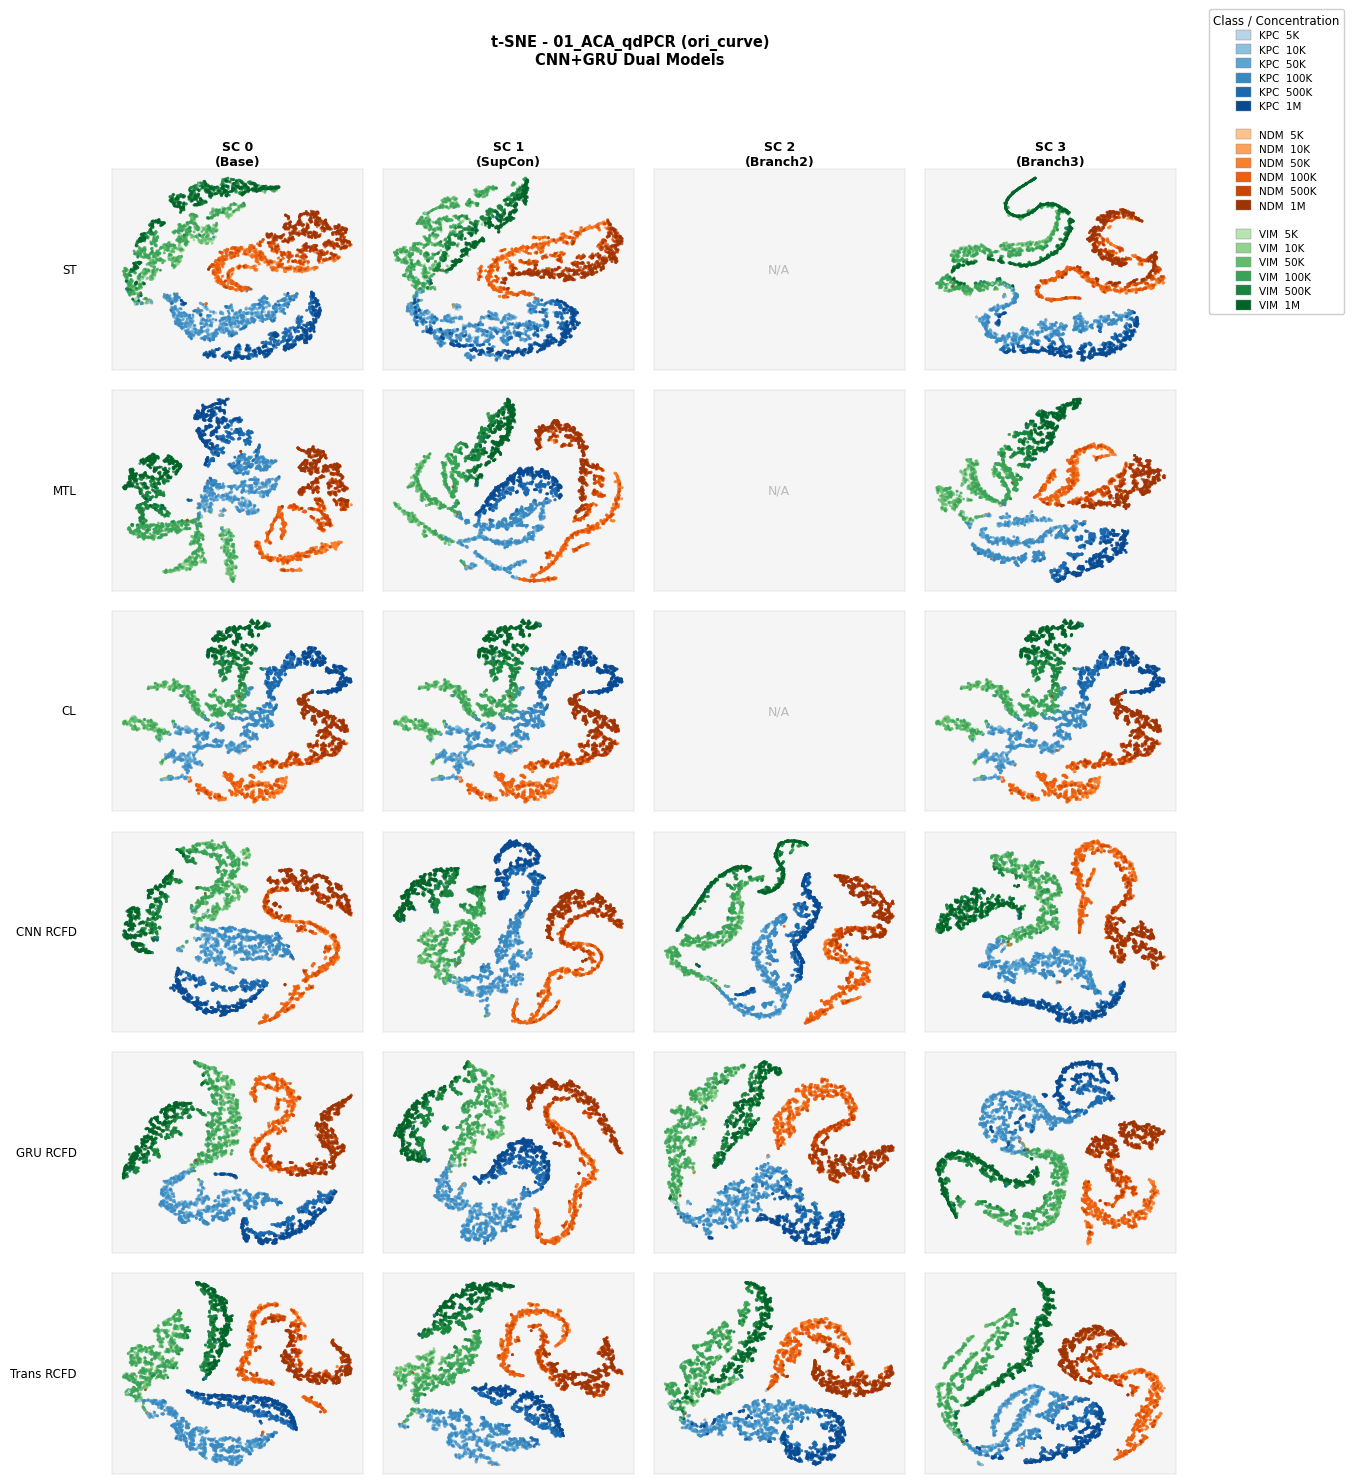


==================================================02_AMCA_qdLAMP==================================================
  Saved: tsne_gru_02_AMCA_qdLAMP_ori_curve.png


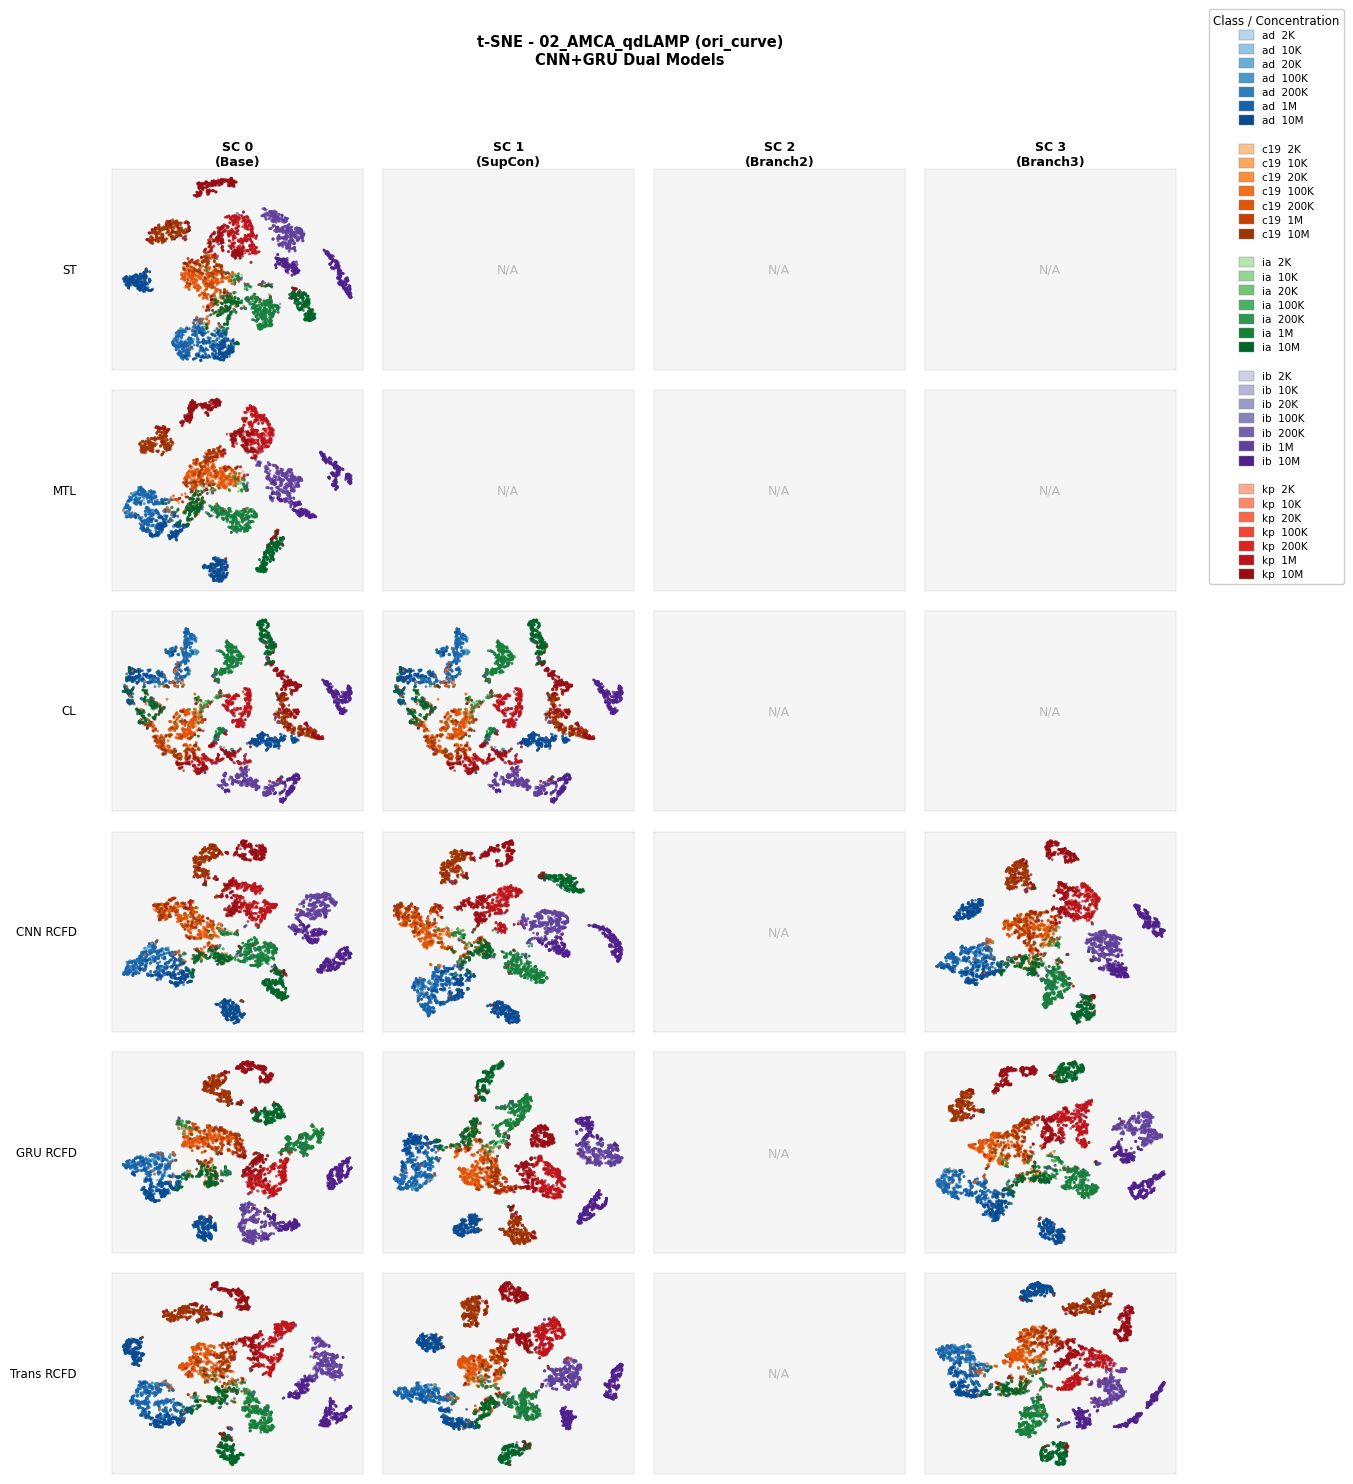


==================================================03_AMCA_qdPCR==================================================
  Saved: tsne_gru_03_AMCA_qdPCR_ori_curve.png


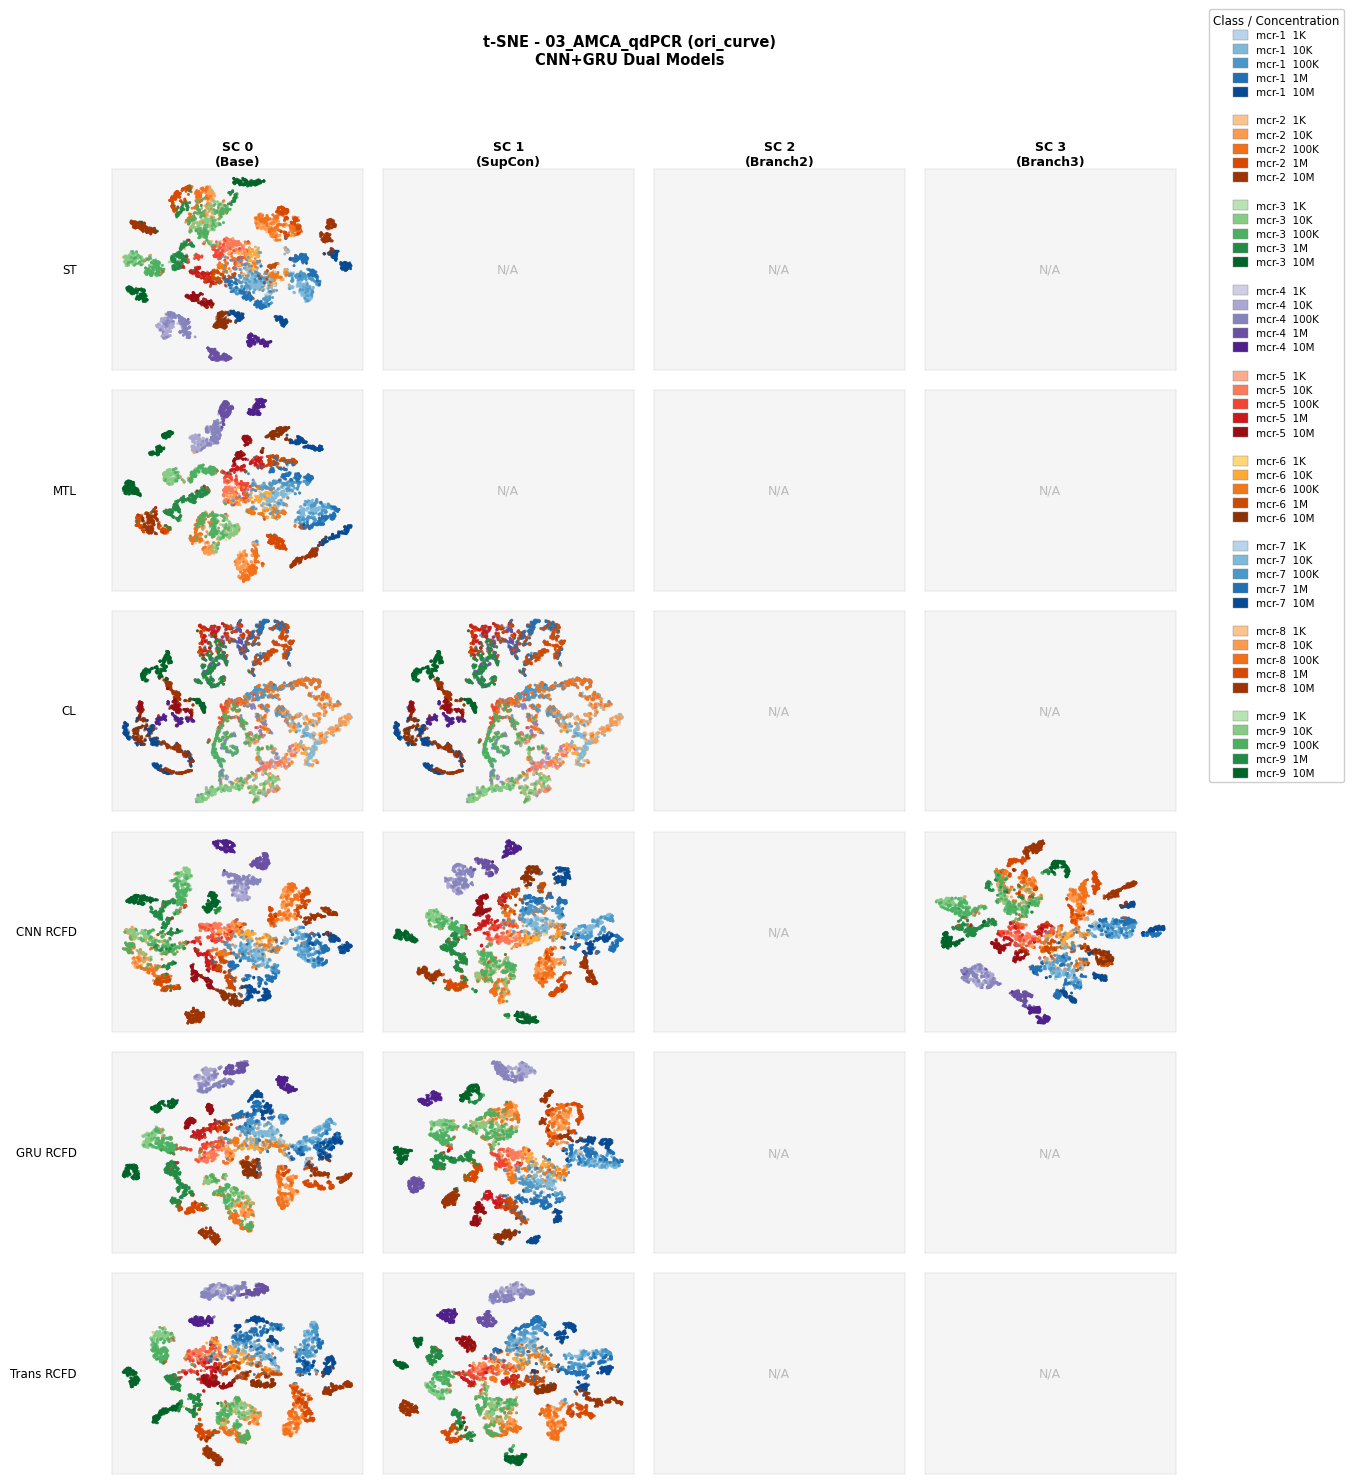

In [25]:
# ── Plot all cached t-SNE results ─────────────────────────────────────────────
for _folder, _r in _tsne_results.items():
    print(f'\n{"="*50}{_folder}{"="*50}')
    # plot_tsne_grid(_r['tsne'], _r['y'], _r['c'], _r['cs'], folder=_folder, save_dir=_r['save_dir'])
    plot_tsne_grid_gru(_r['tsne'], _r['y'], _r['c'], _r['cs'], folder=_folder, save_dir=_r['save_dir'])
